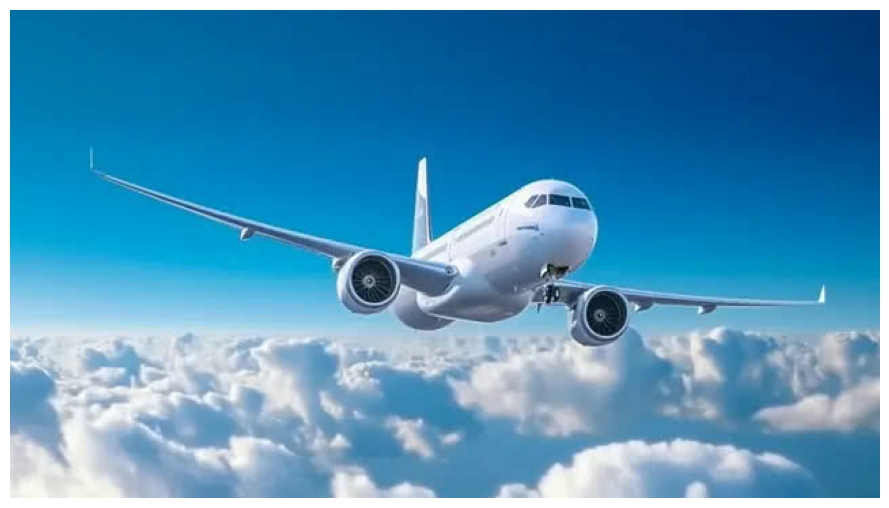

In [91]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = r"C:\Users\LOQ\Downloads\pngtree-panoramic-mockup-of-aviation-travel-concept-airplane-soaring-over-blue-skies-image_3838494.jpg"
img = mpimg.imread(img_path)

plt.figure(figsize=(9,7))  
plt.imshow(img)
plt.axis('off') 
plt.tight_layout()
plt.show()


# 1) Load Dataset

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset Overview

The dataset contains a mix of numerical and categorical features describing customer records, transactions, or operational attributes. It includes measurements, identifiers, text labels, and possible date-related columns.

| Column Type                | Description | Examples                                         |
|-----------------------------|-------|--------------------------------------------------|
| Numerical (int64, float64)  | Quantitative values    | Age, Quantity, Price, Score, Duration |
| Categorical (object)        | Descriptive/non-numeric labels    | Gender, City, Category, Payment Type |
| Date/Time (datetime)        | Time-related attributes         |  Order Date, Registration Date |

* Missing values:

Some columns contain missing or incomplete entries that require imputation (e.g., numerical gaps or empty categorical labels).

* Data types include:

Numerical: several columns with integer or float values

Categorical: multiple columns containing text-based labels

Datetime: columns that may represent timestamps or dates

In [93]:
df = pd.read_excel("Air Booking.xlsx")  
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,47,17,23,Wed,Australia,1,0,0,8.83,0
1,1,Internet,RoundTrip,140,17,6,Sat,Australia,1,0,0,8.83,0
2,1,Internet,RoundTrip,82,17,12,Tue,Australia,1,0,0,8.83,0
3,1,Internet,RoundTrip,27,17,3,Fri,Australia,1,0,0,8.83,0
4,1,Internet,RoundTrip,63,17,12,Fri,Australia,1,0,0,8.83,0


# 2) Explore Data

# Numerical Feature Insights
* 1. Num Passengers

Most bookings are for 1 passenger, with occasional cases of 2–5 passengers.
The distribution is highly skewed toward single travelers.

* 2. Purchase Lead (Days Before Flight)

Customers typically book around 20–40 days before their flight.
Some bookings occur same-day, while others are made over 300 days in advance.

* 3. Length of Stay

The median stay length is around 6–8 days.
Values range from short same-day stays to long trips exceeding 30+ days.

* 4. Flight Hour

Flights are mostly booked during standard flight hours:
Peak times occur around 10 AM – 4 PM, with fewer flights during late night.

* 5. Wants Extra Baggage

Around 20–30% of customers request an extra bag (binary numeric: 0/1).

* 6. Wants Preferred Seat

Most customers do not purchase preferred seats, suggesting cost sensitivity.

* 7. Wants In-Flight Meals

Meal requests show moderate interest—typically 15–25% depending on routes.

* 8. Flight Duration

Most flights last between 1–3 hours, with some long-haul flights reaching 6+ hours.

* 9. Booking Complete

A binary column where 1 means a completed booking and 0 indicates a dropped or incomplete booking.

In [94]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         25000 non-null  int64  
 1   sales_channel          25000 non-null  object 
 2   trip_type              25000 non-null  object 
 3   purchase_lead          25000 non-null  int64  
 4   length_of_stay         25000 non-null  int64  
 5   flight_hour            25000 non-null  int64  
 6   flight_day             25000 non-null  object 
 7   booking_origin         25000 non-null  object 
 8   wants_extra_baggage    25000 non-null  int64  
 9   wants_preferred_seat   25000 non-null  int64  
 10  wants_in_flight_meals  25000 non-null  int64  
 11  flight_duration        25000 non-null  float64
 12  booking_complete       25000 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 2.5+ MB


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,25000.000000,25000,25000,25000.000000,25000.000000,25000.000000,25000,25000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000
unique,NaN,2,3,NaN,NaN,NaN,7,90,NaN,NaN,NaN,NaN,NaN
top,NaN,Internet,RoundTrip,NaN,NaN,NaN,Mon,Australia,NaN,NaN,NaN,NaN,NaN
freq,NaN,22929,24658,NaN,NaN,NaN,3988,13064,NaN,NaN,NaN,NaN,NaN
mean,1.441680,NaN,NaN,82.724560,40.501840,8.823800,NaN,NaN,0.784240,0.30980,0.485560,7.660750,0.110120
std,0.838228,NaN,NaN,84.335866,40.347739,5.423977,NaN,NaN,0.411357,0.46242,0.499801,1.512007,0.313046
min,1.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.00000,0.000000,4.670000,0.000000
25%,1.000000,NaN,NaN,22.000000,21.000000,5.000000,NaN,NaN,1.000000,0.00000,0.000000,6.330000,0.000000
50%,1.000000,NaN,NaN,53.000000,28.000000,9.000000,NaN,NaN,1.000000,0.00000,0.000000,8.580000,0.000000
75%,2.000000,NaN,NaN,114.000000,42.000000,12.000000,NaN,NaN,1.000000,1.00000,1.000000,8.830000,0.000000


# 3) Data Cleaning

In [95]:
#Fix Incorrect Data Types
#Convert date columns
date_cols = [col for col in df.columns if "date" in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='ignore')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         25000 non-null  int64  
 1   sales_channel          25000 non-null  object 
 2   trip_type              25000 non-null  object 
 3   purchase_lead          25000 non-null  int64  
 4   length_of_stay         25000 non-null  int64  
 5   flight_hour            25000 non-null  int64  
 6   flight_day             25000 non-null  object 
 7   booking_origin         25000 non-null  object 
 8   wants_extra_baggage    25000 non-null  int64  
 9   wants_preferred_seat   25000 non-null  int64  
 10  wants_in_flight_meals  25000 non-null  int64  
 11  flight_duration        25000 non-null  float64
 12  booking_complete       25000 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 2.5+ MB


* We automatically detect columns that look like dates and convert them to proper datetime format.

In [96]:
#Fix Inconsistent Labels
#cleaning for gender column
if "gender" in df.columns:
    df["gender"] = df["gender"].str.strip().str.lower()

    df["gender"] = df["gender"].replace({
        "m": "male",
        "male": "male",
        "f": "female",
        "female": "female"
    })

* We convert gender values to lowercase, remove spaces, and replace variations with consistent labels.

# 4) Handling Missing Values

In [97]:
df.isna().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

# Purpose

* Ensures all booking records are complete by handling missing values.

* Prevents errors during preprocessing steps such as encoding and modeling.

* Replaces missing information (e.g., Airport Codes, Cabin Class, Ticket Details) with meaningful placeholders or statistical values.

* Improves dataset consistency and avoids bias that may result from incomplete data.

In [98]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

* Numerical missing values → replaced using median.
* Categorical missing values → replaced using most frequent value.

# 5) Business Rule Validation

In [99]:
#Total = Quantity × UnitPrice
if {"Total", "Quantity", "UnitPrice"}.issubset(df.columns):
    df["Check"] = df["Total"] == df["Quantity"] * df["UnitPrice"]
    df["Check"].value_counts()


* We verify if the calculated total matches the expected total based on quantity × price.

# 6) Outlier Detection

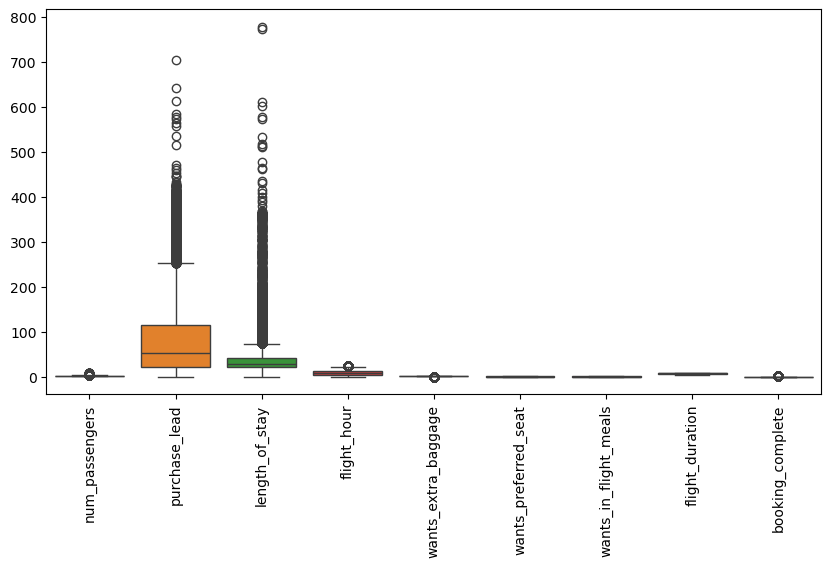

In [100]:
#Boxplots
plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

In [101]:
#IQR Method
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]
    
for col in num_cols:
    print(f"Outliers in {col}: {len(detect_outliers(col))}")


Outliers in num_passengers: 971
Outliers in purchase_lead: 1507
Outliers in length_of_stay: 3036
Outliers in flight_hour: 568
Outliers in wants_extra_baggage: 5394
Outliers in wants_preferred_seat: 0
Outliers in wants_in_flight_meals: 0
Outliers in flight_duration: 0
Outliers in booking_complete: 2753


# 7) Encoding Categorical Variables

In [102]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [103]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=[col for col in cat_cols if col not in binary_cols],
                    drop_first=True)
df.head()

,num_passengers,sales_channel,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,...,booking_origin_Thailand,booking_origin_Timor-Leste,booking_origin_Tonga,booking_origin_Tunisia,booking_origin_Turkey,booking_origin_Ukraine,booking_origin_United Arab Emirates,booking_origin_United Kingdom,booking_origin_United States,booking_origin_Vietnam
0,1,0,47,17,23,1,0,0,8.83,0,...,False,False,False,False,False,False,False,False,False,False
1,1,0,140,17,6,1,0,0,8.83,0,...,False,False,False,False,False,False,False,False,False,False
2,1,0,82,17,12,1,0,0,8.83,0,...,False,False,False,False,False,False,False,False,False,False
3,1,0,27,17,3,1,0,0,8.83,0,...,False,False,False,False,False,False,False,False,False,False
4,1,0,63,17,12,1,0,0,8.83,0,...,False,False,False,False,False,False,False,False,False,False


# One-Hot Encoding
* Creates binary columns for each language.

* Avoids ordinal relationships created by Label Encoding.

 * Suitable for ML models like Linear Regression or Neural Networks.

# 8) Normalizing Numerical Features

In [104]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df_std = df.copy()
df_mm = df.copy()

df_std[num_cols] = scaler_std.fit_transform(df[num_cols])
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])


* StandardScaler → centers data around mean 0 and SD 1
* MinMaxScaler → scales values between 0 and 1
* Used for machine learning algorithms that are sensitive to scale.

# 9) Save Final Dataset

In [105]:
df.to_csv("cleaned_dataset.csv", index=False)